In [46]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
file_path = "imdb_top_1000.csv"
df = pd.read_csv(file_path)

# İlk 5 satır
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [67]:
df['Runtime'] = df['Runtime'].astype(str).str.replace(' min','')
df['Runtime'] = pd.to_numeric(df['Runtime'], errors='coerce').fillna(0).astype(int)

In [69]:
df['Gross'] = df['Gross'].astype(str).str.replace(',', '')
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce').fillna(0)

In [70]:
df['Meta_score'] = df['Meta_score'].fillna(0)
df['Certificate'] = df['Certificate'].fillna('Unknown')

In [71]:
features = ['Runtime', 'No_of_Votes', 'Gross', 'Meta_score']
X = df[features].fillna(0)
y = df['IMDB_Rating']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [74]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [75]:
# Linear Regression
y_pred_lr = lr_model.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

# Random Forest
y_pred_rf = rf_model.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Linear Regression R2: 0.1868545418205938
Linear Regression RMSE: 0.2283109205691499
Random Forest R2: 0.41992207974541196
Random Forest RMSE: 0.19283494237300491


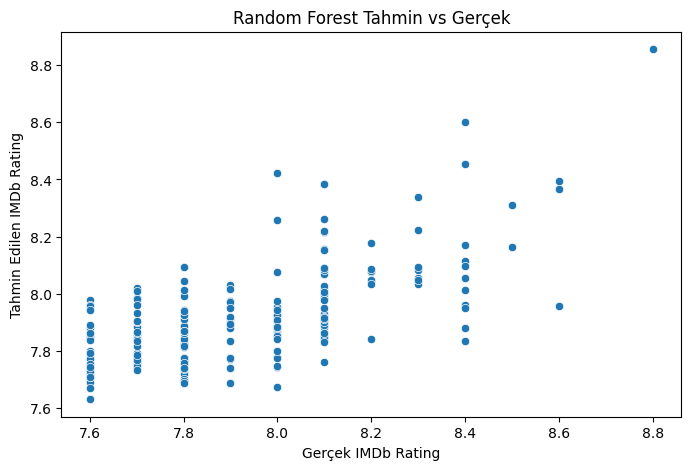

In [76]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Gerçek IMDb Rating")
plt.ylabel("Tahmin Edilen IMDb Rating")
plt.title("Random Forest Tahmin vs Gerçek")
plt.show()

In [77]:
# Genre sütununu temizle ve ayrı türleri listele
df['Genre'] = df['Genre'].astype(str)
genres = df['Genre'].str.get_dummies(sep=', ')
genres.head()

,Action,Adventure,Animation,Biography,Comedy,Crime,Drama,Family,Fantasy,Film-Noir,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [78]:
top_directors = df['Director'].value_counts().head(10).index
df['Director'] = df['Director'].apply(lambda x: x if x in top_directors else 'Other')
directors = pd.get_dummies(df['Director'], prefix='Dir')
directors.head()

,Dir_Akira Kurosawa,Dir_Alfred Hitchcock,Dir_Billy Wilder,Dir_Christopher Nolan,Dir_Clint Eastwood,Dir_Hayao Miyazaki,Dir_Martin Scorsese,Dir_Other,Dir_Stanley Kubrick,Dir_Steven Spielberg,Dir_Woody Allen
0,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,True,False,False,False


In [79]:
X = pd.concat([df[['Runtime','No_of_Votes','Gross','Meta_score']], genres, directors], axis=1)
y = df['IMDB_Rating']

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [81]:
y_pred_rf = rf_model.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: 0.4306108043179876
Random Forest RMSE: 0.19105005888509888


In [82]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(20)

No_of_Votes    0.470159
Meta_score     0.171652
Gross          0.130894
Runtime        0.103512
Action         0.010778
Comedy         0.009011
Crime          0.008368
Romance        0.008212
Thriller       0.007778
Drama          0.007317
War            0.007009
Adventure      0.006802
Biography      0.006123
Animation      0.004886
Sport          0.004884
Western        0.004460
Fantasy        0.004176
Mystery        0.003888
Dir_Other      0.003821
Family         0.003667
dtype: float64